In [1]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, roc_auc_score#,plot_roc_curve
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)
from sklearn.metrics import make_scorer, fbeta_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

random_state=2021

In [2]:
cosmos = pd.read_csv("neo.csv")
cosmos

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


In [3]:
cosmos = cosmos.drop(['id','name','orbiting_body','sentry_object'], axis=1) #porzucenie kolumn
cosmos

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,False
90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,False
90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,False
90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,False


In [4]:
cosmos['hazardous'] = cosmos['hazardous'].astype(int)

In [5]:
X = cosmos.drop(['hazardous'], axis=1) #stworzenie grup x,y 
y = cosmos['hazardous']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from imblearn.under_sampling import RandomUnderSampler
#from collections import Counter


rus = RandomUnderSampler(random_state=42, replacement=True) # losowe balansowanie 
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

In [11]:
# zdefiniowanie walidacji
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=random_state)

# zdefiniowanie prostych modeli
DT_model = DecisionTreeClassifier(random_state=random_state)
RF_model = RandomForestClassifier(random_state=random_state)
XGB_model = XGBClassifier(eval_metric='error', random_state=random_state)
Log_model= LogisticRegression(random_state=random_state)

# dodanie modeli do listy, po której będziemy iterowali
models = [DT_model, RF_model, XGB_model, Log_model]

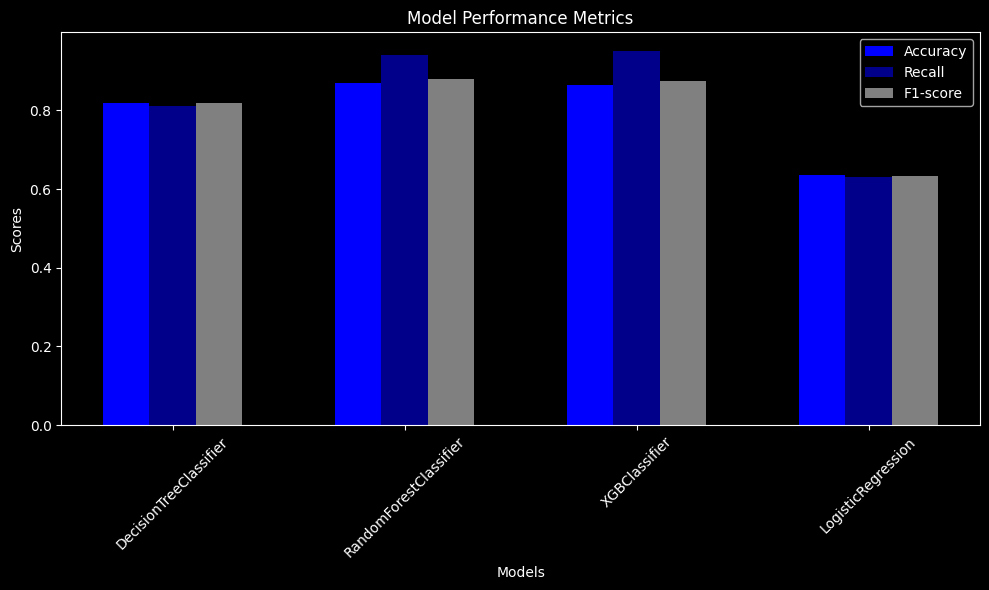

In [16]:
import time 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, recall_score, f1_score
from sklearn.model_selection import cross_val_score

def run_model(model, X, y, cross_val):
    """
    Function to train and evaluate a list of models using cross-validation.

    input:
            model: sklearn estimator model
            X: features for training
            y: target variable
            cross_val: cross-validation strategy
    output:
            metrics: dictionary containing computed metrics
    """
    model_name = type(model).__name__

    recall_scorer = make_scorer(recall_score)
    f1_scorer = make_scorer(f1_score)

    start = time.time()
    accuracy_res = cross_val_score(model, X, y, cv=cross_val, scoring='accuracy')
    recall_res = cross_val_score(model, X, y, cv=cross_val, scoring=recall_scorer)
    f1_res = cross_val_score(model, X, y, cv=cross_val, scoring=f1_scorer)
    end = time.time()
    cross_val_time = end - start

    metrics = {
        'model_name': model_name,
        'accuracy': np.mean(accuracy_res),
        'recall': np.mean(recall_res),
        'f1_score': np.mean(f1_res),
        'cross_val_time': cross_val_time
    }

    return metrics

# Example usage:
# Create an empty list to store metrics for each model
models_metrics = []

# Iterate over models and collect metrics
for model in models:
    metrics = run_model(model, X_train_balanced, y_train_balanced, skf)
    models_metrics.append(metrics)

# Extract metric values for plotting
model_names = [metric['model_name'] for metric in models_metrics]
accuracy_scores = [metric['accuracy'] for metric in models_metrics]
recall_scores = [metric['recall'] for metric in models_metrics]
f1_scores = [metric['f1_score'] for metric in models_metrics]

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.2
index = np.arange(len(model_names))

plt.bar(index, accuracy_scores, bar_width, label='Accuracy', color='blue')
plt.bar(index + bar_width, recall_scores, bar_width, label='Recall', color='darkblue')
plt.bar(index + 2 * bar_width, f1_scores, bar_width, label='F1-score', color='grey')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Metrics')
plt.xticks(index + bar_width, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
